# FraudGuard — Sub-project 2 EDA

Explores the raw synthetic data from sub-project 1 (`../data/*.parquet`).
`ground_truth` is joined here **for analysis only** — the `features/` package
never does this join outside the point-in-time merchant-risk feature.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = "../data"

transactions = pd.read_parquet(f"{DATA_DIR}/transactions.parquet")
customers = pd.read_parquet(f"{DATA_DIR}/customers.parquet")
merchants = pd.read_parquet(f"{DATA_DIR}/merchants.parquet")
devices = pd.read_parquet(f"{DATA_DIR}/devices.parquet")
ground_truth = pd.read_parquet(f"{DATA_DIR}/ground_truth.parquet")

df = transactions.merge(ground_truth[["transaction_id", "fraud_label"]], on="transaction_id")
df = df.merge(merchants[["merchant_id", "merchant_category"]], on="merchant_id")
df = df.merge(customers[["customer_id", "home_country"]], on="customer_id")
df.shape

(519876, 14)

## Fraud prevalence

In [2]:
prevalence = df["fraud_label"].mean()
print(f"Fraud prevalence: {prevalence:.4%} ({df['fraud_label'].sum():,} of {len(df):,} transactions)")

Fraud prevalence: 1.5067% (7,833 of 519,876 transactions)


## Amount distribution: fraud vs. legitimate

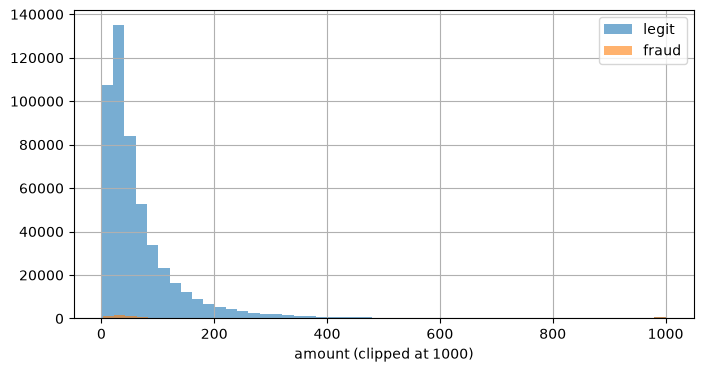

fraud_label
0    43.43
1    61.41
Name: amount, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df["fraud_label"] == 0]["amount"].clip(upper=1000).hist(bins=50, alpha=0.6, label="legit", ax=ax)
df[df["fraud_label"] == 1]["amount"].clip(upper=1000).hist(bins=50, alpha=0.6, label="fraud", ax=ax)
ax.set_xlabel("amount (clipped at 1000)")
ax.legend()
plt.show()

df.groupby("fraud_label")["amount"].median()

## Fraud rate by hour of day

In [4]:
df["hour"] = df["timestamp"].dt.hour
hourly_rate = df.groupby("hour")["fraud_label"].mean().sort_values(ascending=False)
hourly_rate.head(6)

hour
2     0.020132
3     0.018849
1     0.018592
4     0.017474
9     0.016451
13    0.015311
Name: fraud_label, dtype: float64

## Fraud rate by merchant category

In [5]:
category_rate = df.groupby("merchant_category")["fraud_label"].mean().sort_values(ascending=False)
category_rate

merchant_category
crypto         0.048205
gaming         0.017053
electronics    0.012096
travel         0.010172
other          0.009058
fashion        0.008145
dining         0.007697
grocery        0.007205
Name: fraud_label, dtype: float64

## New-device and IP-mismatch signals

In [6]:
device_first_seen = devices.set_index("device_id")["first_seen_at"]
df["is_new_device_txn"] = (
    (df["timestamp"] - df["device_id"].map(device_first_seen)).dt.total_seconds().abs() < 3600
).astype(int)
df["ip_mismatch"] = (df["country"] != df["ip_country"]).astype(int)

for col in ["is_new_device_txn", "ip_mismatch"]:
    flagged = df[df[col] == 1]["fraud_label"].mean()
    not_flagged = df[df[col] == 0]["fraud_label"].mean()
    print(f"{col}: flagged={flagged:.4%} vs not_flagged={not_flagged:.4%}")

is_new_device_txn: flagged=3.9298% vs not_flagged=1.3586%
ip_mismatch: flagged=2.4485% vs not_flagged=1.4901%


## Cross-border transactions

In [7]:
df["is_cross_border"] = (df["country"] != df["home_country"]).astype(int)
df.groupby("is_cross_border")["fraud_label"].mean()

is_cross_border
0    0.014613
1    0.029817
Name: fraud_label, dtype: float64

## Summary: business insights

Filled in from the executed cells above.

1. Overall fraud prevalence is **1.51%** (7,833 of 519,876 transactions).
2. Fraud transactions have a **1.41x** higher median amount than legitimate ones ($61.41 vs $43.43).
3. The riskiest hour of day is **02:00**, at **2.01%** fraud rate vs the overall **1.51%**.
4. The riskiest merchant category is **crypto**, at **4.82%** fraud rate.
5. New-device transactions are **2.89x** more likely to be fraud than established-device transactions (**3.93%** vs **1.36%**).
6. Cross-border transactions are **2.04x** more likely to be fraud than domestic ones (**2.98%** vs **1.46%**).